# Proximal Policy Optimization Algorithm

The fundamental quesion of this solution is: "How can we have maximum possible step size in policy parameters without going too far and getting to a worse policy than the original one before the update?". It is ensured by introducting clip loss function.
It follows the same idea as A2C of having policy network and value network, as weel as multiple workers. However it limits update to policy network. Idea behind this method is to base update on the ratio of new and old policy. Another difference is that it uses multiple networks updates per data sample.



Paper: https://arxiv.org/abs/1707.06347

Open AI blog post: https://openai.com/blog/openai-baselines-ppo/

In [1]:
import os
import pprint
import random
import warnings
import numpy as np

from gym import Env
from gym.spaces import Discrete, Box
from Environment.simulator import *
from Environment.my_utils import *
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

import gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecCheckNan
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env

PPO_path = os.path.join('Training', 'Saved Models', 'PPO_model')
save_path = os.path.join('Training', 'Saved Models')
log_path = os.path.join('Training', 'Logs')


warnings.filterwarnings("ignore")

Prepare the enviroment

In [2]:
# Replicate runs
TEST_EPISODES = 10

# SIM PARAMETERS
SLA = 2.5
VM_TYPE1 = 5
VM_TYPE2 = 3
VM_TYPE3 = 1
STEPS = 100
ALPHA = 0.5
BETA = 0.5

env = Sim(sla = SLA,
          vm_1 = VM_TYPE1,
          vm_2 = VM_TYPE2,
          vm_3 = VM_TYPE3,
          steps = STEPS,
          alpha = ALPHA,
          beta = BETA)

In [3]:
# check_env(env, warn=0, skip_render_check=1)

Adding callbacks

In [4]:
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=190, verbose=1)
eval_callback = EvalCallback(env, 
                             callback_on_new_best=stop_callback, 
                             eval_freq=10000, 
                             best_model_save_path=save_path, 
                             verbose=1)

Train the model

In [5]:
model = PPO('MlpPolicy', env, verbose = 1, tensorboard_log=log_path)
model.learn(total_timesteps=2000, callback=eval_callback)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to Training\Logs\PPO_4


Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is being closed
Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is b

Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is being closed
Traceback (most recent call last):
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\queues.py", line 241, in _feed
    send_bytes(obj)
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 200, in send_bytes
    self._send_bytes(m[offset:offset + size])
  File "C:\Users\dkapczyn\Anaconda3\lib\multiprocessing\connection.py", line 280, in _send_bytes
    ov, err = _winapi.WriteFile(self._handle, buf, overlapped=True)
BrokenPipeError: [WinError 232] The pipe is b

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | 57.8     |
| time/              |          |
|    fps             | 0        |
|    iterations      | 1        |
|    time_elapsed    | 6291     |
|    total_timesteps | 2048     |
---------------------------------


In [7]:
#model_path = os.path.join('Training', 'Saved Models', 'best_model')
#model = PPO.load(model_path, env=env)

Evaluate the policy

In [10]:
evaluate_policy(model, env, n_eval_episodes=10, render=True)

(89.7, 6.104096984812742)

Test the model

In [8]:
# restart env
obs = env.reset()
done = False

culumative_reward = 0
step = 0
value = []
quality_of_service = []
utility_function = []
queue_len = []
cost_lst = []
no_of_vm_lst = []
steps_lst = []


while True:
    action, _states = model.predict(obs)
    obs, rewards, done, info = env.step(action)
    
    # save the resuls
    culumative_reward+=rewards
    step +=1
    value.append(culumative_reward)
    steps_lst.append(step)
    quality_of_service.append(info['Quality of Service'])
    utility_function.append(obs)
    cost_lst.append(info['Current cost'])
    no_of_vm_lst.append(info['VM type I'] + info['VM type II'] + info['VM type III'])
    queue_len.append(info['Queue len'])
    
    if done: 
        print('info', info)
        break

info {'Quality of Service': 6.1998, 'Current cost': 160.0, 'Queue len': 12, 'Timer': 1.9355459213256836, 'VM type I': 6, 'VM type II': 6, 'VM type III': 2}


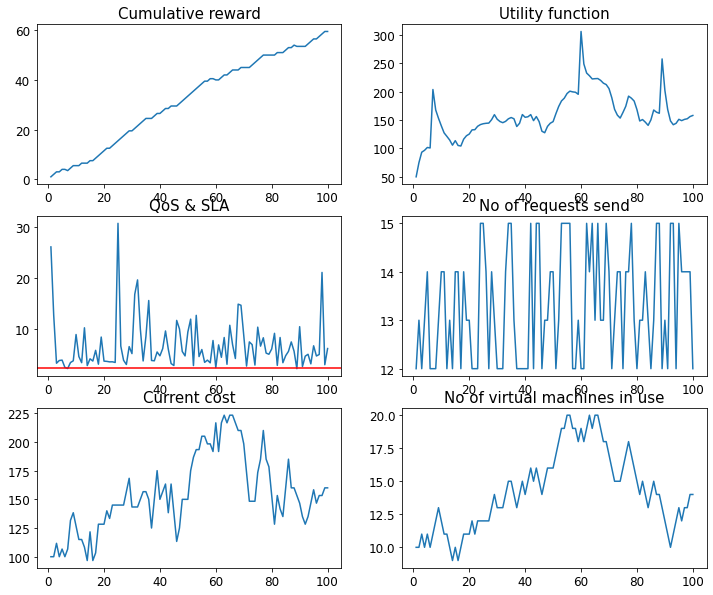

In [9]:
viz_performance(cumulative_reward=value,
               utility_function=utility_function,
               qos=quality_of_service,
               queue_len=queue_len,
               cost = cost_lst,
               no_of_vm = no_of_vm_lst,
               steps=steps_lst,
               sla=SLA)

In [11]:
# detailed results:
print("Cumulative reward at the end of the test: ", value[-1])
print("Avg cost per step: ", np.round(np.mean(cost_lst), 2))
print("Avg quality of service: ", np.round(np.mean(quality_of_service), 2))
print("Avg no of requests: ", np.mean(queue_len))
print("Avg no of virtual machines: ", np.mean(no_of_vm_lst))

Cumulative reward at the end of the test:  59.5
Avg cost per step:  154.75
Avg quality of service:  6.81
Avg no of requests:  13.29
Avg no of virtual machines:  14.27
